In [86]:
import numpy as np
import pandas as pd

In [87]:
def map_eth(idx):
    """
    Maps an index to an ethnicity category based on the specified ranges.
    
    Args:
        idx (int): The index to be mapped.
        
    Returns:
        int: The ethnicity category (0 for Chinese, 1 for Indian, 2 for Malay).
    """
    if idx in [0, 1]:
        return 0  # Chinese
    elif idx in [2, 3]:
        return 1  # Indian
    elif idx in [4, 5]:
        return 2  # Malay
    elif idx in [6, 7]:
        return 0  #  use Chn


In [88]:
import numpy as np
import pandas as pd
import os


In [89]:
num_files = 8  # Change this to the actual number of files to read

age_matrix_vec = []

FLAG = 2050

# FLAG = 2023

def load_age_matrices(FLAG):
    """
    Loads age matrices based on the specified FLAG value.
    
    Args:
        FLAG (int): Flag indicating which data to load (2050, 2023, or 0)
        
    Returns:
        list: List of age matrices
    """
    age_matrix_vec = []
    num_files = 8

    if FLAG == 2050:
        # Directory containing the binary files
        data_dir = "../../output/20250526_151118"

        # Read each binary file
        for i in range(8):
            filename = os.path.join(data_dir, f"forecast_matrix_{i}.bin")
            
            # Get file size to determine number of rows
            file_size = os.path.getsize(filename)
            num_rows = file_size // (27 * 4)  # 27 columns, 4 bytes per int32
            
            # Create numpy matrix of appropriate size
            matrix = np.zeros((num_rows, 27), dtype=np.int32)
            
            # Read binary data into matrix
            with open(filename, 'rb') as f:
                # Read all values at once into flattened array
                data = np.fromfile(f, dtype=np.int32)
                # Reshape into matrix
                matrix = data.reshape((num_rows, 27))
            
            age_matrix_vec.append(matrix)
        
        for idx in range(8):
            matrix = age_matrix_vec[idx]  # Extract the matrix
            # Check each row, and keep it if not all values are negative
            filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
            age_matrix_vec[idx] = filtered_matrix


    elif FLAG == 2023:
        path = "/Users/haolong/Documents/demos_v_matrix/output/"
        for i in range(num_files):
            # Create the filename dynamically
            filename = f"popu_matrix_{i}.csv"
            matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
            age_matrix_vec.append(matrix)

        for idx in range(8):
            matrix = age_matrix_vec[idx]  # Extract the matrix
            # Check each row, and keep it if not all values are negative
            filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
            age_matrix_vec[idx] = filtered_matrix

    elif FLAG == 0:
        # Create combined matrices for each index
        age_matrix_vec_2023 = load_age_matrices(2023)
        age_matrix_vec_2050 = load_age_matrices(2050)
        
        for i in range(8):
            # Get dimensions
            rows_2023 = age_matrix_vec_2023[i].shape[0]
            rows_2050 = age_matrix_vec_2050[i].shape[0]
            max_rows = rows_2050

            # Create empty matrix filled with -1
            combined = np.full((max_rows, 61), -1)

            # Fill left block with 2023 data
            combined[:rows_2023, :34] = age_matrix_vec_2023[i]

            # Fill right block with 2050 data
            combined[:rows_2050, 34:] = age_matrix_vec_2050[i]

            age_matrix_vec.append(combined)
            

    return age_matrix_vec

In [90]:
age_matrix_vec = load_age_matrices(0)


In [91]:
age_matrix_vec[0].shape

(92749, 61)

In [92]:
for idx in range(8):
    matrix = age_matrix_vec[idx]
    print(f"Matrix {idx} shape:", matrix.shape)

Matrix 0 shape: (92749, 61)
Matrix 1 shape: (98107, 61)
Matrix 2 shape: (20330, 61)
Matrix 3 shape: (20266, 61)
Matrix 4 shape: (16226, 61)
Matrix 5 shape: (14384, 61)
Matrix 6 shape: (13465, 61)
Matrix 7 shape: (14927, 61)


In [93]:
# 55 - 69 is too high 

# adjust 

In [94]:
new_array = np.load('../data/albu_transit/single_year_transit.npy')
result = new_array 
coef = [0.9, 1, 1.1, 0.9, 1.25, 0.8] # the most closest

a1 = 1.38
a2 = 1.29

result[0,0] = new_array[0,0] * coef[0]

result[0,1] = new_array[0,1] * coef[2]  # Malay male 
result[1,1] = new_array[1,1] * coef[3]  # Malay male

result[0,2] = new_array[0,2] * coef[4]  # Indian male
result[1,2] = new_array[1,2] * coef[5]  # Indian male


In [95]:
new_coef = [0.9, 1, 1.3 * 1.38, 0.9 * 1.38, 1.3 * 1.29, 0.8 * 1.29]  

In [96]:
# for i in range(14):
#     result[:, :, i, 1] *= 1 + i / 14 * 1.6


In [97]:
0.006 / 0.007

0.8571428571428571

In [98]:
result[:, :, 14:16, 1] 

array([[[0.00573736, 0.00703557],
        [0.01111297, 0.01365078],
        [0.01070517, 0.01314065]],

       [[0.01195004, 0.0120267 ],
        [0.01715014, 0.01724135],
        [0.01289196, 0.01297102]]])

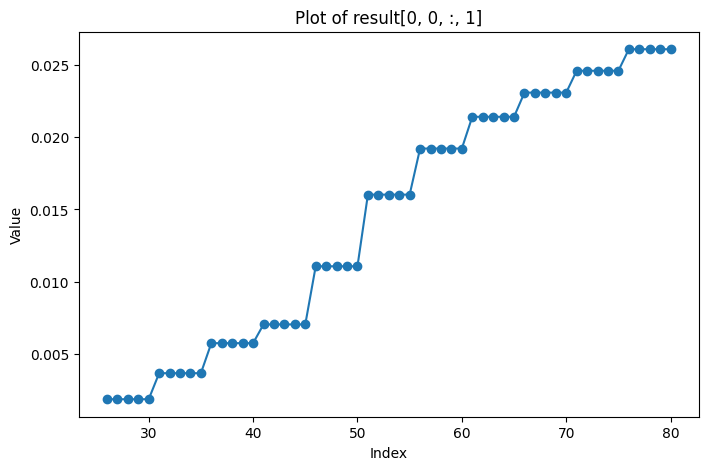

In [99]:
import matplotlib.pyplot as plt

# Extract the data
y_values = new_array[0, 0, :, 1]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(range(26,81), y_values, marker='o', linestyle='-')

# Add labels and title
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Plot of result[0, 0, :, 1]")

# Show the plot
plt.show()


In [100]:
# result[:, :, 35:40, 1] = result[:, :, 35:40, 1] - ((result[:, :, 35, 1] - result[:, :, 30, 1]).reshape(2, 3, 1)) * 0.9

In [101]:
new_array[0, 0, 0, 1]

0.0018543250854101468

In [102]:
new_array[0, 0, 0, 1]

0.0018543250854101468

In [103]:
new_array = np.load('../data/albu_transit/single_year_transit.npy')

import numpy as np


shape = (2, 3, 61, 3)  # Example: (i_max, j_max, rows, cols)
result = np.random.rand(*shape)  # Replace with actual data
# Loop through the specified ranges
for i in range(2):  # Assuming range 2 means 0 to 1 (2 elements)
    for j in range(3):  # Assuming range 3 means 0 to 2 (3 elements)
        # Add 6 rows at the beginning of result[i,j,:,:]
        new_rows = np.tile(new_array[0, 0, 0, :], (6, 1))  # Creating 6 rows like result[0,0,:,:]
        result[i, j, :, :] = np.vstack((new_rows, new_array[i, j, :, :]))

        # Change result[i,j,0:6,0] to 20 - 25
        result[i, j, 0:6, 0] = np.arange(20, 26)

# Print or use result as needed


coef = [0.9, 1, 1.3, 0.9, 1.3, 0.8] # the most closest

result[0,0] = result[0,0] * coef[0]

result[0,1] = result[0,1] * coef[2]  # Malay male
result[1,1] = result[1,1] * coef[3]  # Malay male

result[0,2] = result[0,2] * coef[4]  # Indian male
result[1,2] = result[1,2] * coef[5]  # Indian male

print(result)

[[[[1.80000000e+01 1.85432509e-03 0.00000000e+00]
   [1.89000000e+01 1.85432509e-03 0.00000000e+00]
   [1.98000000e+01 1.85432509e-03 0.00000000e+00]
   ...
   [7.02000000e+01 2.60968390e-02 1.61728630e-02]
   [7.11000000e+01 2.60968390e-02 1.61728630e-02]
   [7.20000000e+01 2.60968390e-02 1.61728630e-02]]

  [[2.60000000e+01 2.67846957e-03 0.00000000e+00]
   [2.73000000e+01 2.67846957e-03 0.00000000e+00]
   [2.86000000e+01 2.67846957e-03 0.00000000e+00]
   ...
   [1.01400000e+02 6.23924692e-02 4.11767110e-02]
   [1.02700000e+02 6.23924692e-02 4.11767110e-02]
   [1.04000000e+02 6.23924692e-02 4.11767110e-02]]

  [[2.60000000e+01 2.67846957e-03 0.00000000e+00]
   [2.73000000e+01 2.67846957e-03 0.00000000e+00]
   [2.86000000e+01 2.67846957e-03 0.00000000e+00]
   ...
   [1.01400000e+02 5.17095468e-02 3.25049920e-02]
   [1.02700000e+02 5.17095468e-02 3.25049920e-02]
   [1.04000000e+02 5.17095468e-02 3.25049920e-02]]]


 [[[2.00000000e+01 2.06036121e-03 0.00000000e+00]
   [2.10000000e+01 2.

result[:, :, 5:10, 1] = result[:, :, 5:10, 1] + ((result[:, :, 10, 1] - result[:, :, 5, 1]).reshape(2, 3, 1)) * 0.8
result[:, :, 0:5, 1] = result[:, :, 0:5, 1] + ((result[:, :, 5, 1] - result[:, :, 0, 1]).reshape(2, 3, 1)) * 0.8
result[:, :, 15:, 1] = result[:, :, 15:, 1] - ((result[:, :, 15, 1] - result[:, :, 10, 1]).reshape(2, 3, 1)) * 0.9

result[:, :, 20:, 1] = result[:, :, 20:, 1] - ((result[:, :, 20, 1] - result[:, :, 15, 1]).reshape(2, 3, 1)) * 0.9
result[:, :, 25:, 1] = result[:, :, 25:, 1] - ((result[:, :, 25, 1] - result[:, :, 20, 1]).reshape(2, 3, 1)) * 0.9
result[:, :, 30:, 1] = result[:, :, 30:, 1] - ((result[:, :, 30, 1] - result[:, :, 29, 1]).reshape(2, 3, 1)) * 0.9

In [104]:
# result[:, :, 15:, 1] = result[:, :, 15:, 1] - ((result[:, :, 15, 1] - result[:, :, 10, 1]).reshape(2, 3, 1)) * 0.9
# result[:, :, 15:20, 1] = result[:, :, 15:20, 1] + ((result[:, :, 15, 1] - result[:, :, 10, 1]).reshape(2, 3, 1)) * 0.95
# result[:, :, 10:15, 1] = result[:, :, 10:15, 1] + ((result[:, :, 15, 1] - result[:, :, 10, 1]).reshape(2, 3, 1)) * 0.95
# result[:, :, 5:10, 1] = result[:, :, 5:10, 1] + ((result[:, :, 10, 1] - result[:, :, 5, 1]).reshape(2, 3, 1)) * 0.95
# result[:, :, 0:5, 1] = result[:, :, 0:5, 1] + ((result[:, :, 5, 1] - result[:, :, 0, 1]).reshape(2, 3, 1)) * 0.95


# 41 - 46
result[:, :, 21:26, 1] = result[:, :, 21:26, 1] + ((result[:, :, 21, 1] - result[:, :, 16, 1]).reshape(2, 3, 1)) * 0.95
result[:, :, 16:21, 1] = result[:, :, 16:21, 1] + ((result[:, :, 21, 1] - result[:, :, 16, 1]).reshape(2, 3, 1)) * 0.95
result[:, :, 11:16, 1] = result[:, :, 11:16, 1] + ((result[:, :, 16, 1] - result[:, :, 11, 1]).reshape(2, 3, 1)) * 0.95
# 26 - 31
result[:, :, 6:11, 1] = result[:, :, 6:11, 1] + ((result[:, :, 11, 1] - result[:, :, 6, 1]).reshape(2, 3, 1)) * 0.95

result[:, :, 0:6, 1] = result[:, :, 0:6, 1] + ((result[:, :, 6, 1] - result[:, :, 4, 1]).reshape(2, 3, 1)) * 0.95
 # 66 - 71

In [105]:
# result[:, :, 16:, 1] = result[:, :, 16:, 1] - ((result[:, :, 16, 1] - result[:, :, 11, 1]).reshape(2, 3, 1)) * 0.95
# result[:, :, 21:, 1] = result[:, :, 21:, 1] - ((result[:, :, 21, 1] - result[:, :, 16, 1]).reshape(2, 3, 1)) * 0.95


result[:, :, 26:, 1] = result[:, :, 26:, 1] - ((result[:, :, 26, 1] - result[:, :, 21, 1]).reshape(2, 3, 1)) * 0.95
result[:, :, 31:, 1] = result[:, :, 31:, 1] - ((result[:, :, 31, 1] - result[:, :, 26, 1]).reshape(2, 3, 1)) * 0.95
result[:, :, 36:, 1] = result[:, :, 36:, 1] - ((result[:, :, 36, 1] - result[:, :, 35, 1]).reshape(2, 3, 1)) * 0.95
result[:, :, 41:, 1] = result[:, :, 41:, 1] - ((result[:, :, 41, 1] - result[:, :, 36, 1]).reshape(2, 3, 1)) * 0.95 

## lower bound

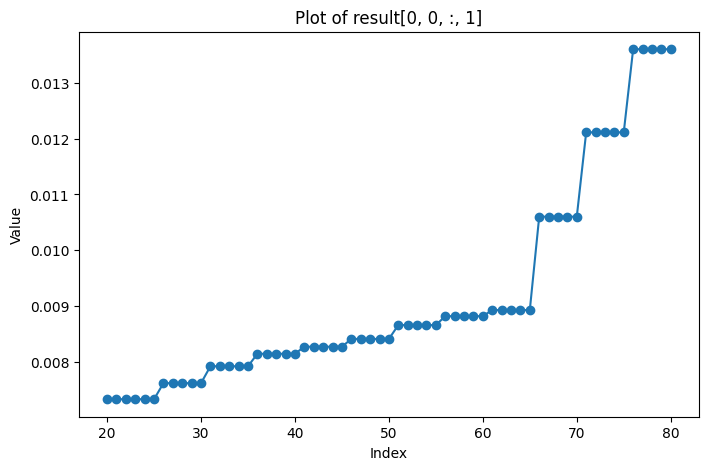

In [106]:
import matplotlib.pyplot as plt

# Extract the data
y_values = result[0, 0, :, 1]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(range(20,81), y_values, marker='o', linestyle='-')

# Add labels and title
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Plot of result[0, 0, :, 1]")

# Show the plot
plt.show()

In [107]:

result[:, :, 11:, 1] = result[:, :, 11:, 1] - ((result[:, :, 16, 1] - result[:, :, 11, 1]).reshape(2, 3, 1)) * 0.95
# 26 - 31

# result[:, :, 16:, 1] = result[:, :, 16:, 1] - ((result[:, :, 21, 1] - result[:, :, 16, 1]).reshape(2, 3, 1)) * 0.95

# result[:, :, 21:, 1] = result[:, :, 21:, 1] - ((result[:, :, 21, 1] - result[:, :, 16, 1]).reshape(2, 3, 1)) * 0.95


In [108]:
new_array[0, 0, 20, 1]

0.012290323690095972

In [109]:
new_array[0, 0, 0, 1]

0.002060361206011274

In [110]:

# for i in range(14):
#     result[:, :, 14+i, 1] *= 0.1 + i / 14 * 0.2


# for i in range(14):
#     result[:, :, 28+i, 1] *= 0.1 + i / 14 * 0.2

# result[:, :, 14:29, 1] = result[:, :, 14:29, 1] * 0.

In [111]:
# result[:, :, 29:44, 1] = result[:, :, 29:44, 1] * 0.5

[1.1, 1, 1.1, 0.9, 1.25, 0.8]

          Group  Simulated Prevalence (%)  NPHS Reported Prevalence (%)
0      Chn Male                     14.86                          11.8
1    Chn Female                     12.97                          13.8
2    Malay Male                     19.01                          20.7
3  Malay Female                     16.84                          17.2
4      Ind Male                     17.98                          17.6
5    Ind Female                     10.86                          11.0

Ethnicity 0: 8617 / 57984 (14.86%)
Ethnicity 1: 7899 / 60886 (12.97%)
Ethnicity 2: 2049 / 10778 (19.01%)
Ethnicity 3: 1815 / 10776 (16.84%)
Ethnicity 4: 1384 / 7699 (17.98%)
Ethnicity 5: 770 / 7091 (10.86%)
Ethnicity 6: 296 / 2563 (11.55%)
Ethnicity 7: 285 / 3138 (9.08%)

----------------------------------------------------

[1, 1,1, 1, 1.25, 1.0]

          Group  Simulated Prevalence (%)  NPHS Reported Prevalence (%)
0      Chn Male                     13.99                          11.8
1    Chn Female                     13.31                          13.8
2    Malay Male                     17.70                          20.7
3  Malay Female                     18.09                          17.2
4      Ind Male                     18.64                          17.6
5    Ind Female                     12.88                          11.0


[0.9, 1.1, 1.2, 1, 1.05, 1.]

          Group  Simulated Prevalence (%)  NPHS Reported Prevalence (%)
0      Chn Male                     12.84                          11.8
1    Chn Female                     13.42                          13.8
2    Malay Male                     20.30                          20.7
3  Malay Female                     17.86                          17.2
4      Ind Male                     17.05                          17.6
5    Ind Female                     13.00                          11.0

-------

          Group  
0      Chn Male           [0.8, 0.9]    
1    Chn Female          [1, 1.2]        
2    Malay Male            [1.1, 1.3]  
3  Malay Female            [0.9, 1]       
4      Ind Male           [1.05, 1.25]         
5    Ind Female          [0.8, 1.0]  



[0.8, 1.2, 1.3, 1, 1.05, 1.]


In [112]:
coef

[0.9, 1, 1.3, 0.9, 1.3, 0.8]

In [113]:
0.003 - 0.007

-0.004

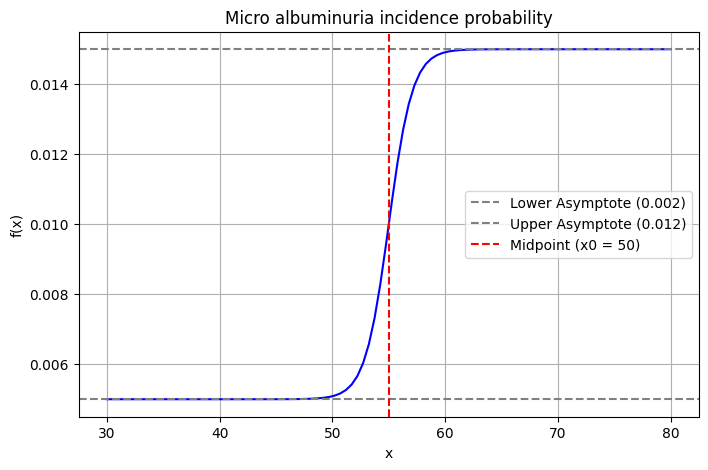

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# Define the logistic function
def logistic_function(x, A=0.005, x0=55, k=0.95):
    L = A + 0.01
    return A + (L - A) / (1 + np.exp(-k * (x - x0)))

# Generate x values
x = np.linspace(30, 80, 100)  # Range centered around x0
y = logistic_function(x)

# Plot the function
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='b')
plt.axhline(y=0.005, linestyle='--', color='gray', label="Lower Asymptote (0.002)")
plt.axhline(y=0.015, linestyle='--', color='gray', label="Upper Asymptote (0.012)")
plt.axvline(x=55, linestyle='--', color='red', label="Midpoint (x0 = 50)")

# Labels and title
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Micro albuminuria incidence probability")
plt.legend()
plt.grid()

# Show the plot
plt.show()


# 0.75

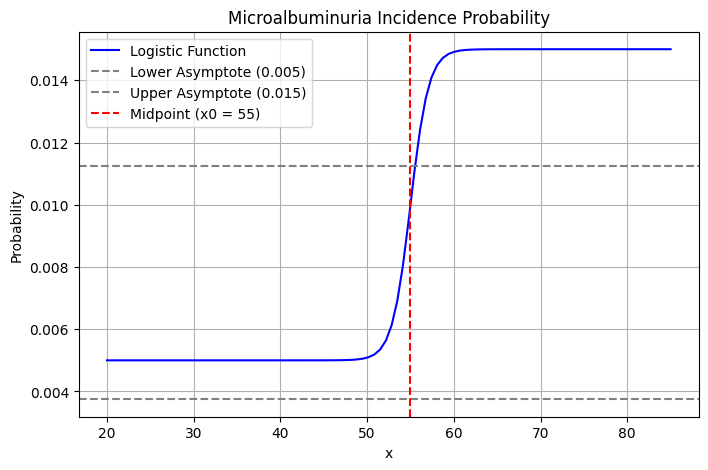

In [115]:
import numpy as np
import matplotlib.pyplot as plt

# Define the logistic function
def logistic_function(x, A=0.005, x0=55, k=0.95):
    L = A + 0.01
    return (A + (L - A) / (1 + np.exp(-k * (x - x0))) ) #* 0.75

# Generate x values
x = np.linspace(20, 85, 100)  # Range centered around x0
y = logistic_function(x)

# Plot the function
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='b', label='Logistic Function')
plt.axhline(y=0.005* 0.75, linestyle='--', color='gray', label="Lower Asymptote (0.005)")
plt.axhline(y=0.015* 0.75 , linestyle='--', color='gray', label="Upper Asymptote (0.015)")
plt.axvline(x=55, linestyle='--', color='red', label="Midpoint (x0 = 55)")

# Labels and title
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Microalbuminuria Incidence Probability")
plt.legend()
plt.grid(True)

# Save the plot as a high-quality image (optional)
plt.savefig('microalbuminuria_probability_plot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [116]:
coef = [0.9, 1.1, 1.2 * 1.4, 1. * 1.4, 1.25 * 1.3 , 1 * 1.3, 1.25* 1.4, 0.9* 1.4]

In [117]:
coef = [0.9, 1.1, 1.4 * 1.4, 1.2 * 1.4, 1.3 * 1.3 , 1 * 1.3, 1.3* 1.4, 1.* 1.4]

In [118]:
# this is the one we use 
coef = [0.9, 1.1, 1.5 * 1.4, 1.3 * 1.4, 1.3 * 1.3 , 1 * 1.3, 1.3* 1.4, 1.* 1.4]

In [119]:
# 0.003 - 0.007

In [120]:
len(np.arange(0.003, 0.0072, 0.0002))

21

In [121]:
np.concatenate([np.arange(0.001, 0.003, 0.0002), np.arange(0.005, 0.0072, 0.0002)])

array([0.001 , 0.0012, 0.0014, 0.0016, 0.0018, 0.002 , 0.0022, 0.0024,
       0.0026, 0.0028, 0.005 , 0.0052, 0.0054, 0.0056, 0.0058, 0.006 ,
       0.0062, 0.0064, 0.0066, 0.0068, 0.007 ])

In [122]:
age_matrix_vec[0]

array([[ 0,  1,  2, ..., 58, 59, 60],
       [ 0,  1,  2, ..., 58, 59, 60],
       [ 0,  1,  2, ..., 58, 59, 60],
       ...,
       [-1, -1, -1, ..., -1, -1,  0],
       [-1, -1, -1, ..., -1, -1,  0],
       [-1, -1, -1, ..., -1, -1,  0]])

In [123]:
## save the results 
import numpy as np

# Initialize a list of 8, each will contain a (5, matrix.shape) 3D matrix
albu_1_mat_storage = [None] * 8  

cols = age_matrix_vec[0].shape[1]

for idx in range(8):  # Loop over the 8 groups
    rows = age_matrix_vec[idx].shape[0]
    
    # Create a 3D matrix to store results for all 5 age thresholds (30-34)
    albu_1_mat_3d = np.zeros((21, rows, cols), dtype=int) 

    eth = map_eth(idx)
    gen = idx % 2
    x = 20
    #for A_index, A_actual in enumerate(np.arange(0.003, 0.0072, 0.0002)):  # Loop over the 5 age thresholds
    for A_index, A_actual in enumerate(np.concatenate([np.arange(0.001, 0.003, 0.0002), np.arange(0.005, 0.0072, 0.0002)])):  # Loop over the 5 age thresholds
        matrix = age_matrix_vec[idx]
        mask = (matrix >= x) & (matrix <= 74)
        transition_matrix = np.zeros_like(matrix, dtype=float)

        transition_matrix[mask] = logistic_function(matrix[mask],A_actual) * coef[idx]

        random_matrix = np.random.rand(*matrix.shape)
        comparison_matrix = random_matrix < transition_matrix 

        albu_1_mat = np.zeros_like(matrix, dtype=int)  

        for i in range(rows):
            first_one_index = np.argmax(comparison_matrix[i, :])
            if comparison_matrix[i, first_one_index]:
                albu_1_mat[i, first_one_index:cols] = 1  

        death_mask = (matrix == -1)
        albu_1_mat[death_mask] = -1

        # Transition from state 1 to state 2
        state_1 = (albu_1_mat == 1) & (matrix <= 80)
        albu_1_mat[state_1] = np.where(
            np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2] * 1.2, 
            2, 
            1
        )
        
        for j in range(rows):
            first_2_idx = np.argmax(albu_1_mat[j, :] == 2)
            if albu_1_mat[j, first_2_idx] != 2:
                continue
            else:
                albu_1_mat[j, first_2_idx:cols] = 2  

        albu_1_mat[death_mask] = -1

        # Remove ages outside the range 18–74
        condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
        albu_1_mat[condition] = 3  

        # Store in the 3D matrix
        albu_1_mat_3d[A_index] = albu_1_mat  

    # Store the 3D matrix in the list
    albu_1_mat_storage[idx] = albu_1_mat_3d  

# Convert list elements to NumPy arrays
albu_1_mat_storage = [np.array(mat) for mat in albu_1_mat_storage]

# Accessing example:
# albu_1_mat_storage[idx][x_index, :, :] → Matrix for group `idx` at `x=30 + x_index`
idx = 2  # Third group
A_index = 3  # Corresponding to age x=33
print(f"Shape of stored matrix for idx={idx}, x={30 + A_index}: {albu_1_mat_storage[idx][A_index].shape}")


Shape of stored matrix for idx=2, x=33: (20330, 61)


import numpy as np

# Initialize a list of 8, each will contain a (5, matrix.shape) 3D matrix
albu_1_mat_storage = [None] * 8  

cols = age_matrix_vec[0].shape[1]

for idx in range(8):  # Loop over the 8 groups
    rows = age_matrix_vec[idx].shape[0]
    
    # Create a 3D matrix to store results for all 5 age thresholds (30-34)
    albu_1_mat_3d = np.zeros((5, rows, cols), dtype=int)

    eth = map_eth(idx)
    gen = idx % 2

    for x_index, x in enumerate([20,23,25,27,30]):  # Loop over the 5 age thresholds
        matrix = age_matrix_vec[idx]
        mask = (matrix >= x) & (matrix <= 74)
        transition_matrix = np.zeros_like(matrix, dtype=float)

        transition_matrix[mask] = result[gen, eth, matrix[mask] - 20, 1]

        random_matrix = np.random.rand(*matrix.shape)
        comparison_matrix = random_matrix < transition_matrix * 0.75

        albu_1_mat = np.zeros_like(matrix, dtype=int)  

        for i in range(rows):
            first_one_index = np.argmax(comparison_matrix[i, :])
            if comparison_matrix[i, first_one_index]:
                albu_1_mat[i, first_one_index:cols] = 1  

        death_mask = (matrix == -1)
        albu_1_mat[death_mask] = -1

        # Transition from state 1 to state 2
        state_1 = (albu_1_mat == 1) & (matrix <= 80)
        albu_1_mat[state_1] = np.where(
            np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2], 
            2, 
            1
        )
        
        for j in range(rows):
            first_2_idx = np.argmax(albu_1_mat[j, :] == 2)
            if albu_1_mat[j, first_2_idx] != 2:
                continue
            else:
                albu_1_mat[j, first_2_idx:cols] = 2  

        albu_1_mat[death_mask] = -1

        # Remove ages outside the range 18–74
        condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
        albu_1_mat[condition] = 3  

        # Store in the 3D matrix
        albu_1_mat_3d[x_index] = albu_1_mat  

    # Store the 3D matrix in the list
    albu_1_mat_storage[idx] = albu_1_mat_3d  

# Convert list elements to NumPy arrays
albu_1_mat_storage = [np.array(mat) for mat in albu_1_mat_storage]

# Accessing example:
# albu_1_mat_storage[idx][x_index, :, :] → Matrix for group `idx` at `x=30 + x_index`
idx = 2  # Third group
x_index = 3  # Corresponding to age x=33
print(f"Shape of stored matrix for idx={idx}, x={30 + x_index}: {albu_1_mat_storage[idx][x_index].shape}")


In [124]:
## save the results 


In [125]:
FLAG = 0 #2023 #2050

In [126]:


if FLAG == 2050:
    # Ensure the directory exists
    save_dir = '../data/new_2050/albu_matrix'
    os.makedirs(save_dir, exist_ok=True)

    # Save each matrix
    for idx, matrix in enumerate(albu_1_mat_storage):
        file_path = os.path.join(save_dir, f"albu_mat_{FLAG}_{idx}.npy")
        np.save(file_path, matrix)
        print(f"Saved: {file_path}")
if FLAG == 2023:
    # Ensure the directory exists
    save_dir = '../data/new_2023/albu_matrix'
    os.makedirs(save_dir, exist_ok=True)

    # Save each matrix
    for idx, matrix in enumerate(albu_1_mat_storage):
        file_path = os.path.join(save_dir, f"albu_mat_{FLAG}_{idx}.npy")
        np.save(file_path, matrix)
        print(f"Saved: {file_path}")
if FLAG == 0:
    # Ensure the directory exists
    save_dir = '../data/new_90_50/albu_matrix'
    os.makedirs(save_dir, exist_ok=True)

    # Save each matrix
    for idx, matrix in enumerate(albu_1_mat_storage):
        file_path = os.path.join(save_dir, f"albu_mat_{FLAG}_{idx}.npy")
        np.save(file_path, matrix)
        print(f"Saved: {file_path}")


Saved: ../data/new_90_50/albu_matrix/albu_mat_0_0.npy
Saved: ../data/new_90_50/albu_matrix/albu_mat_0_1.npy
Saved: ../data/new_90_50/albu_matrix/albu_mat_0_2.npy
Saved: ../data/new_90_50/albu_matrix/albu_mat_0_3.npy
Saved: ../data/new_90_50/albu_matrix/albu_mat_0_4.npy
Saved: ../data/new_90_50/albu_matrix/albu_mat_0_5.npy
Saved: ../data/new_90_50/albu_matrix/albu_mat_0_6.npy
Saved: ../data/new_90_50/albu_matrix/albu_mat_0_7.npy


In [127]:
import os
import numpy as np

In [128]:
FLAG = 0

In [129]:
albu_1_mat_storage[0]

array([[[ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  0,  0,  0],
        ...,
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1,  0]],

       [[ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  0,  0,  0],
        ...,
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1,  0]],

       [[ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  0,  0,  0],
        ...,
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1,  0]],

       ...,

       [[ 0,  3,  3, ...,  1,  1,  1],
        [ 0,  3,  3, ...,  0,  0,  0],
        [ 0,  3,  3, ...,  0,  0,  0],
        ...,
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1,  0],
        [-1, -1, -1, ..., -1, -1

In [130]:
# Load and verify matrices
albu_1_mat_storage = []
if FLAG == 2050:
    save_dir = '../data/new_2050/albu_matrix'
    for idx in range(8):
        file_path = os.path.join(save_dir, f"albu_mat_{FLAG}_{idx}.npy")
        matrix = np.load(file_path)
        albu_1_mat_storage.append(matrix)
        print(f"Loaded: {file_path}, Shape: {matrix.shape}")
elif FLAG == 2023:
    save_dir = '../data/new_2023/albu_matrix'
    for idx in range(8):
        file_path = os.path.join(save_dir, f"albu_mat_{FLAG}_{idx}.npy")
        matrix = np.load(file_path)
        albu_1_mat_storage.append(matrix)
        print(f"Loaded: {file_path}, Shape: {matrix.shape}")
elif FLAG == 0:
    save_dir = '../data/new_90_50/albu_matrix'
    for idx in range(8):
        file_path = os.path.join(save_dir, f"albu_mat_{FLAG}_{idx}.npy")
        matrix = np.load(file_path)
        albu_1_mat_storage.append(matrix)
        print(f"Loaded: {file_path}, Shape: {matrix.shape}")

Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_0.npy, Shape: (21, 92749, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_1.npy, Shape: (21, 98107, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_2.npy, Shape: (21, 20330, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_3.npy, Shape: (21, 20266, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_4.npy, Shape: (21, 16226, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_5.npy, Shape: (21, 14384, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_6.npy, Shape: (21, 13465, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_7.npy, Shape: (21, 14927, 61)


In [131]:
# Initialize lists to store percentages
state_1_per = []
state_2_per = []

for x_index in range(21):  # Loop over 5 different age thresholds (30-34)
    total_state_1 = 0
    total_state_2 = 0
    total_population = 0

    for idx in range(8):  # Loop over the 8 groups
        albu_1_mat = albu_1_mat_storage[idx][x_index]  # Extract the matrix for current x value
        last_col = albu_1_mat[:, -29]  # Get the second last

        total_state_1 += np.sum(last_col == 1)  # Count state 1
        total_state_2 += np.sum(last_col == 2)  # Count state 2
        total_population += np.sum((last_col == 0) | (last_col == 1) | (last_col == 2))  # Count all valid states

    # Compute percentages
    state_1_per.append((total_state_1 / total_population) * 100)
    state_2_per.append((total_state_2 / total_population) * 100)




In [132]:
# Output results
print("state_1_per:", state_1_per)
print("state_2_per:", state_2_per)

state_1_per: [4.997077192874504, 5.510875919145925, 5.817309171461096, 6.262806510168292, 6.603698120173522, 7.041811525089992, 7.3390148601667535, 7.622065655477956, 8.182629295757314, 8.559209919084394, 12.494846629541888, 12.841891517706058, 13.304618035258283, 13.585822847121804, 13.968556748607822, 14.217764514044855, 14.761098975479186, 14.806017906039443, 15.24843860566717, 15.558563824877702, 16.099436975048455]
state_2_per: [0.596252653601206, 0.6233270775005384, 0.6670153524290066, 0.7347014121773375, 0.7790050149216995, 0.842999107774667, 0.9039165615481648, 0.9592960649786174, 0.9445281973971634, 1.0515952373627049, 1.6127742054579577, 1.6989200996831062, 1.6693843645201982, 1.7936805833307694, 1.7979878780420269, 1.8662892656062517, 1.9505891763837186, 1.9265913915638557, 1.962280404885703, 2.033658431529397, 1.9942774513121864]


# from 0.003 
state_1_per: [8.954865704704181, 9.341291573085561, 9.761560471341108, 9.938774882318555, 10.375042303787342, 10.823616281574008, 11.100513798726272, 11.343568286004368, 11.864750946066517, 12.287481155585638, 12.588376457557764, 12.98034027628219, 13.27877426699074, 13.791957665446267, 14.142694520505799, 14.26206811678922, 14.633726117589147, 15.05522567147648, 15.356736301264498, 15.567178414300217, 16.042826815986217]
state_2_per: [1.140202442851429, 1.1315878534289143, 1.2257330092606835, 1.2515767775282283, 1.237424237762668, 1.3623357843891333, 1.4478663507983878, 1.4614035627480542, 1.5333969172076423, 1.5247823277851276, 1.5924683875334584, 1.6503092022274866, 1.7629141925360736, 1.6989200996831062, 1.7579915700089224, 1.8453681198658585, 1.8349075469956617, 1.925976063747962, 1.9733563055717933, 2.010891302341322, 2.104421130357198]

In [ ]:
# Output results
# print("state_1_per:", state_1_per)
# print("state_2_per:", state_2_per)

Ethnicity 0: 7908 / 57984 (13.64%)
Ethnicity 1: 10339 / 60886 (16.98%)
Ethnicity 2: 2179 / 10778 (20.22%)
Ethnicity 3: 2361 / 10776 (21.91%)
Ethnicity 4: 1525 / 7699 (19.81%)
Ethnicity 5: 1079 / 7091 (15.22%)
Ethnicity 6: 255 / 2563 (9.95%)
Ethnicity 7: 406 / 3138 (12.94%)

          Group  Simulated Prevalence (%)  NPHS Reported Prevalence (%)
0      Chn Male                      3.06                          11.8
1    Chn Female                      1.98                          13.8
2    Malay Male                      3.97                          20.7
3  Malay Female                      3.38                          17.2
4      Ind Male                      4.29                          17.6
5    Ind Female                      0.10                          11.0



Ethnicity 0: 7497 / 57984 (12.93%)
Ethnicity 1: 8211 / 60886 (13.49%)
Ethnicity 2: 1981 / 10778 (18.38%)
Ethnicity 3: 1754 / 10776 (16.28%)
Ethnicity 4: 1409 / 7699 (18.30%)
Ethnicity 5: 737 / 7091 (10.39%)
Ethnicity 6: 255 / 2563 (9.95%)
Ethnicity 7: 295 / 3138 (9.40%)ß